In [122]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from agent_src import generate_sequence, plot_transition_network
from tqdm import tqdm

#### SET SEED
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [124]:
# 1. Setup Environment
states = ['A', 'B', 'C', 'D', 'E']
# Example Ground Truth: A predictable cycle with 10% noise
G = np.array([
    [0.05, 0.90, 0.05, 0.00, 0.00], # A -> B
    [0.00, 0.05, 0.90, 0.05, 0.00], # B -> C
    [0.00, 0.00, 0.05, 0.90, 0.05], # C -> D
    [0.05, 0.00, 0.00, 0.05, 0.90], # D -> E
    [0.90, 0.05, 0.00, 0.00, 0.05], # E -> A
])

# Generate material: A list of sequences (phrases)
# Using the generate_sequence function from earlier steps
material = generate_sequence(G, states, length=200) 
print(material)


['ABC', 'DEA', 'BCD', 'EAA', 'BCD', 'EBC', 'CDEE', 'EAB', 'CDEA', 'BCD', 'EABD', 'EABC', 'DEAB', 'CDE', 'BCD', 'EABC', 'DEA', 'BCCD', 'EAB', 'BBCD', 'EABC', 'DDD', 'EABC', 'EAB', 'CDEA', 'ACDE', 'ABC', 'DEA', 'BCE', 'ABCD', 'EAB', 'BCCC', 'DEAB', 'CDE', 'ABC', 'DABC', 'DEAB', 'CDA', 'BCD', 'EAB', 'CDE', 'EBC', 'DEAB', 'CDEA', 'ABCD', 'EABC', 'DEA', 'BCE', 'ABC', 'DEAB', 'CDEB', 'CDE', 'ABB', 'CDEE', 'EABC', 'DEA', 'BCD', 'DEAB']


In [ ]:
'''
Student v1: MarkovLearner with Forgetting

FEATURES:
- Student learns via repeated exposure
- Forget factor simulates memory decay
- predicts next state stochastically based on learned probabilities

ASSUMPTIONS:

'''
class StudentMarkovLearner:
    def __init__(self, states=['A', 'B', 'C', 'D', 'E'], forget_factor=0.95):
        self.states = states
        self.state_to_idx = {s: i for i, s in enumerate(states)}
        self.n = len(states)
        self.forget_factor = forget_factor
        # Initial state: All zeros (Stage 5)
        self.matrix = np.zeros((self.n, self.n))
        
    def update(self, current_char, next_char):
        """Update weights based on observed transition."""
        i, j = self.state_to_idx[current_char], self.state_to_idx[next_char]
        
        # Apply forgetting factor to the entire matrix
        self.matrix *= self.forget_factor
        
        # Reinforce the observed transition (Weighted learning)
        self.matrix[i, j] += 1
        
        #convert to probabilities
        self.matrix = self.matrix / (self.matrix.sum(axis=1, keepdims=True)+1e-8)

    def predict(self, current_char):
        """Predict the next state stochastically."""
        i = self.state_to_idx[current_char]
        row = self.matrix[i]
        
        if np.sum(row) == 0:
            # If nothing learned yet, pick randomly
            return np.random.choice(self.states)
        
        # Normalize row to create a probability distribution
        probabilities = row / np.sum(row)
        return np.random.choice(self.states, p=probabilities)

    def get_matrix_df(self):
        """Returns the adjacency matrix as a readable DataFrame."""

        return pd.DataFrame(self.matrix, index=self.states, columns=self.states)
    
    def study(self, sequence):
        """Study a sequence of transitions."""
        for i in range(len(sequence) - 1):
            curr, nxt = sequence[i], sequence[i+1]
            prediction = self.predict(curr)
            self.update(curr, nxt)


In [119]:
# 2. Initialize Student Group with varying Forget Factors
forget_rates = [0.9, 0.92, 0.95]
student_group = [MarkovLearner(states=states, forget_factor=x) for x in forget_rates]

# 3. Study Procedure with engagement tracking
def proc_study(student, material, ground_truth):
    MAE_collect = []
    
    for phrase in tqdm(material, desc=f"Student (λ={student.forget_factor})"):
        # Student processes the phrase
        student.study(phrase)
        
        # Compare the LEARNED probability matrix to Ground Truth
        student_knowledge = student.learned_matrix
        
        # Mean Absolute Error: Compare learned probabilities to ground truth
        mae = np.mean(np.abs(student_knowledge - ground_truth))
        MAE_collect.append(mae)
        
    return MAE_collect

# 4. Diagnostic check with engagement display
print(f'Ground Truth[0,:]: {ground_truth[0,:]}')

student = MarkovLearner(states=states, forget_factor=1.0)
for phrase in tqdm(material[:10], desc=f"Diagnostic (λ={student.forget_factor})"):
    results = student.study(phrase)
    student_knowledge = student.learned_matrix
    
    engagement_stats = student.get_engagement_stats()

    res = [r[0] for r in results]
    accuracy = sum(res) / len(res) if res else 0

    print(
        f'Accuracy: {accuracy:.1%},\t',
        f'Engagement: {engagement_stats["current_state"]}\t',
        f'Learned[0,:]: {student_knowledge[0,:].round(3)}'
    )


Ground Truth[0,:]: [0.05 0.9  0.05 0.   0.  ]


Diagnostic (λ=1.0): 100%|██████████| 10/10 [00:00<00:00, 2176.37it/s]

Accuracy: 33.3%,	 Engagement: optimal	 Learned[0,:]: [0.182 0.273 0.182 0.182 0.182]
Accuracy: 33.3%,	 Engagement: optimal	 Learned[0,:]: [0.158 0.368 0.158 0.158 0.158]
Accuracy: 0.0%,	 Engagement: frustrated	 Learned[0,:]: [0.236 0.395 0.123 0.123 0.123]
Accuracy: 0.0%,	 Engagement: frustrated	 Learned[0,:]: [0.236 0.395 0.123 0.123 0.123]
Accuracy: 0.0%,	 Engagement: frustrated	 Learned[0,:]: [0.236 0.395 0.123 0.123 0.123]
Accuracy: 100.0%,	 Engagement: frustrated	 Learned[0,:]: [0.236 0.395 0.123 0.123 0.123]
Accuracy: 66.7%,	 Engagement: optimal	 Learned[0,:]: [0.212 0.457 0.11  0.11  0.11 ]
Accuracy: 0.0%,	 Engagement: frustrated	 Learned[0,:]: [0.212 0.457 0.11  0.11  0.11 ]
Accuracy: 50.0%,	 Engagement: optimal	 Learned[0,:]: [0.212 0.457 0.11  0.11  0.11 ]
Accuracy: 66.7%,	 Engagement: optimal	 Learned[0,:]: [0.196 0.496 0.102 0.102 0.102]


In [120]:
class AdaptiveTutor:
    def __init__(self, ground_truth, states, material):
        """
        Tutor selects the best phrases from material based on student ZPD.
        
        Args:
            ground_truth: The true transition matrix
            states: List of state names
            material: List of phrase strings to select from
        """
        self.ground_truth = ground_truth
        self.states = states
        self.material = material  # Fixed set of phrases to choose from
        
    def compute_zpd_gaps(self, student_learned_matrix):
        """
        Identify the transitions where the student benefits most from learning.
        Returns a dict of transition (i,j) -> ZPD score.
        
        ZPD score = how close is the student's learned probability to 0.5?
        (0.5 = maximum uncertainty, best learning opportunity)
        """
        zpd_scores = {}
        
        for i in range(len(self.states)):
            for j in range(len(self.states)):
                if self.ground_truth[i, j] == 0:
                    continue  # Skip non-existent transitions
                    
                p_learned = student_learned_matrix[i, j]
                # Score: 1.0 at p=0.5 (uncertain), 0.0 at p=0 or p=1 (certain)
                score = 1 - abs(p_learned - 0.5) * 2
                zpd_scores[(i, j)] = score
        
        return zpd_scores
    
    def phrase_contains_transition(self, phrase, state_from_idx, state_to_idx):
        """Check if phrase contains the transition state_i -> state_j."""
        state_from = self.states[state_from_idx]
        state_to = self.states[state_to_idx]
        
        for k in range(len(phrase) - 1):
            if phrase[k] == state_from and phrase[k+1] == state_to:
                return True
        return False
    
    def rate_phrase(self, phrase, zpd_scores):
        """
        Rate a phrase based on how well it targets the ZPD gaps.
        Higher score = better for current student state.
        """
        score = 0
        count = 0
        
        for k in range(len(phrase) - 1):
            current_char = phrase[k]
            next_char = phrase[k+1]
            
            i = self.states.index(current_char)
            j = self.states.index(next_char)
            
            if (i, j) in zpd_scores:
                score += zpd_scores[(i, j)]
                count += 1
        
        return score / count if count > 0 else 0
    
    def select_phrase(self, student_learned_matrix):
        """
        Select the best phrase from material for the student's current state.
        Returns the phrase string.
        """
        zpd_scores = self.compute_zpd_gaps(student_learned_matrix)
        
        if not zpd_scores:
            # No valid transitions, pick randomly
            return np.random.choice(self.material)
        
        best_phrase = None
        best_score = -1
        
        for phrase in self.material:
            phrase_score = self.rate_phrase(phrase, zpd_scores)
            if phrase_score > best_score:
                best_score = phrase_score
                best_phrase = phrase
        
        return best_phrase if best_phrase else np.random.choice(self.material)


Adaptive Learning Sessions: 100%|██████████| 50/50 [00:00<00:00, 849.98it/s]


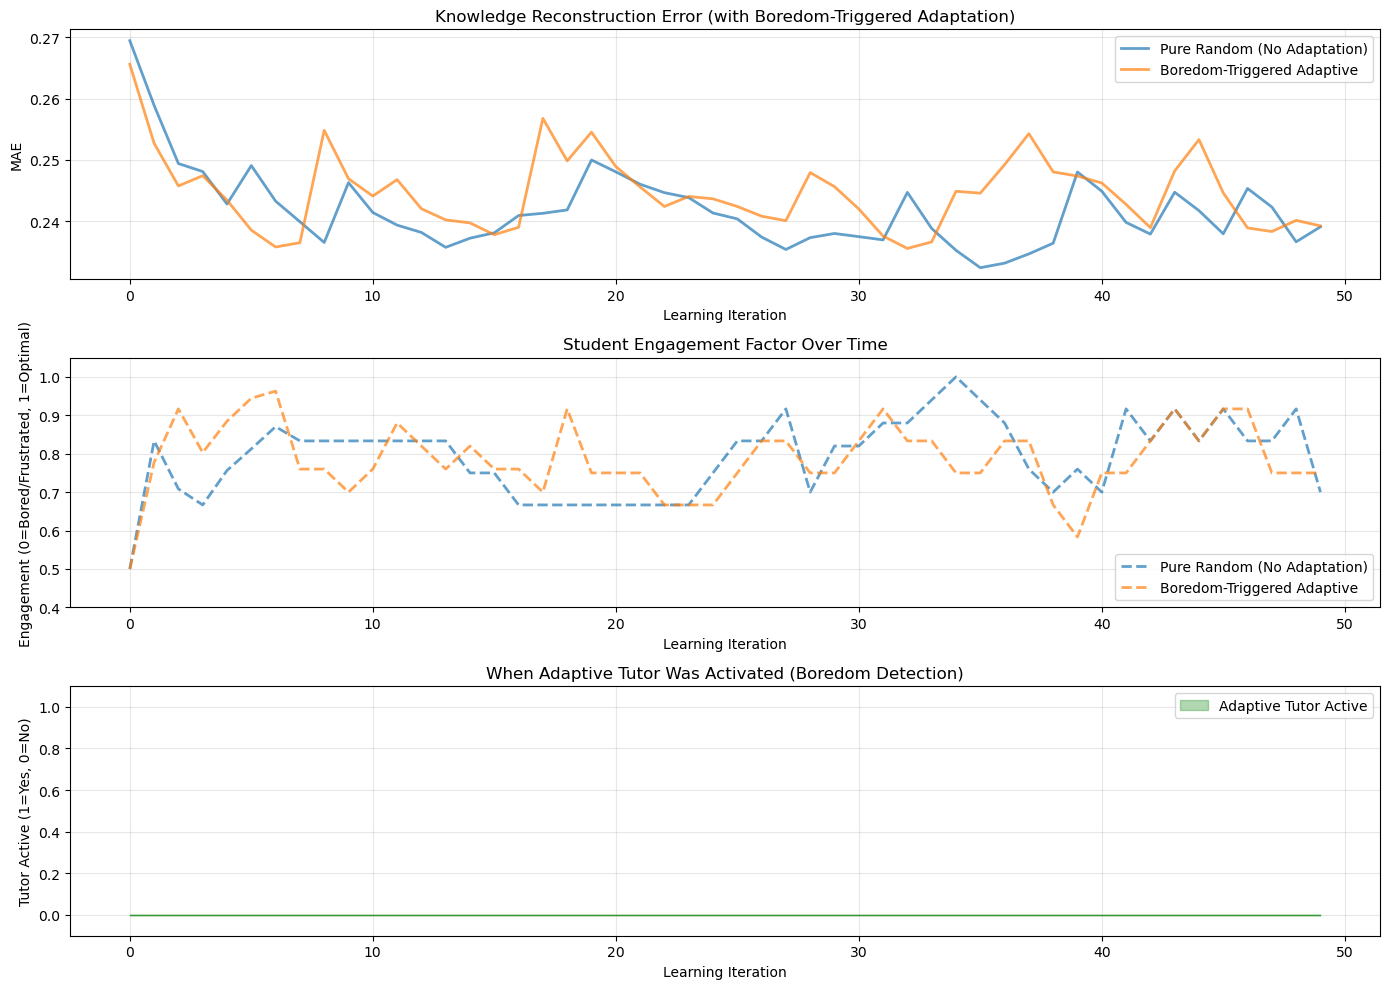


=== Adaptive Tutor Activation Statistics ===
Total iterations: 50
Tutor activations: 0 (0.0%)
Activation pattern: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

=== Final Engagement State (Boredom-Triggered) ===
State: frustrated
Engagement: 75.00%
Accuracy: 15.0%
State Distribution: {'bored': 0, 'frustrated': 20, 'optimal': 0}


In [121]:
import numpy as np
from tqdm import tqdm
import seaborn as sns

# 1. Initialize
student = MarkovLearner(states=states, forget_factor=0.95)
tutor = AdaptiveTutor(ground_truth, states, material)
num_iterations = 50

# 2. Adaptive Learning Loop - Tutor Activates Only When Bored

def proc_run_boredom_adaptive(student, tutor):
    """
    Adaptive tutor activates only when student is BORED.
    This provides a natural intervention: when the student is overfit/not challenged,
    the tutor presents ZPD-targeted material to re-engage them.
    """
    history_mae = []
    history_engagement = []
    tutor_activation_log = []
    
    for i in tqdm(range(num_iterations), desc="Adaptive Learning Sessions"):
        
        # --- PHRASE SELECTION: Check current engagement state ---
        engagement_stats = student.get_engagement_stats()
        current_state = engagement_stats.get('current_state', 'neutral')
        
        # Use adaptive tutor ONLY when student is bored
        use_adaptive = (current_state == 'bored')
        tutor_activation_log.append(use_adaptive)
        
        if use_adaptive:
            selected_phrase = tutor.select_phrase(student.learned_matrix)
        else:
            selected_phrase = np.random.choice(material)
        
        # --- STUDY STEP ---
        for j in range(len(selected_phrase) - 1):
            c, n = selected_phrase[j], selected_phrase[j+1]
            
            prediction = student.predict(c)
            was_correct = (prediction == n)
            
            student.update(c, n, was_correct)
        
        # --- METRICS ---
        mae = np.mean(np.abs(student.learned_matrix - ground_truth))
        history_mae.append(mae)
        
        # Track engagement state after this iteration
        engagement_stats = student.get_engagement_stats()
        history_engagement.append(engagement_stats)

    return history_mae, history_engagement, tutor_activation_log

# Run scenarios with different strategies
scenarios = [
    (MarkovLearner(states=states, forget_factor=0.80), AdaptiveTutor(ground_truth, states, material), "Pure Random (No Adaptation)"),
    (MarkovLearner(states=states, forget_factor=0.80), AdaptiveTutor(ground_truth, states, material), "Boredom-Triggered Adaptive"),
]

# Process first scenario (pure random - no tutor)
student_random = scenarios[0][0]
history_mae_random = []
history_engagement_random = []

for i in tqdm(range(num_iterations), desc="Pure Random Sessions"):
    selected_phrase = np.random.choice(material)
    
    for j in range(len(selected_phrase) - 1):
        c, n = selected_phrase[j], selected_phrase[j+1]
        prediction = student_random.predict(c)
        was_correct = (prediction == n)
        student_random.update(c, n, was_correct)
    
    mae = np.mean(np.abs(student_random.learned_matrix - ground_truth))
    history_mae_random.append(mae)
    history_engagement_random.append(student_random.get_engagement_stats())

# Process second scenario (boredom-triggered adaptive)
student_adaptive = scenarios[1][0]
mae_hist_adaptive, engagement_hist_adaptive, tutor_log = proc_run_boredom_adaptive(student_adaptive, scenarios[1][1])

results = [
    (history_mae_random, history_engagement_random, "Pure Random (No Adaptation)"),
    (mae_hist_adaptive, engagement_hist_adaptive, "Boredom-Triggered Adaptive"),
]

# Visualization: MAE over time
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

for mae_hist, engagement_hist, label in results:
    ax1.plot(mae_hist, label=label, linewidth=2, alpha=0.7)

ax1.set_title("Knowledge Reconstruction Error (with Boredom-Triggered Adaptation)")
ax1.set_xlabel("Learning Iteration")
ax1.set_ylabel("MAE")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Visualization: Engagement state over time
for mae_hist, engagement_hist, label in results:
    engagement_factors = [e['current_engagement'] for e in engagement_hist]
    ax2.plot(engagement_factors, label=label, linewidth=2, alpha=0.7, linestyle='--')

ax2.set_title("Student Engagement Factor Over Time")
ax2.set_xlabel("Learning Iteration")
ax2.set_ylabel("Engagement (0=Bored/Frustrated, 1=Optimal)")
ax2.set_ylim([0.4, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)

# Visualization: When tutor was activated
tutor_activations = np.array(tutor_log, dtype=int)
ax3.fill_between(range(len(tutor_activations)), 0, tutor_activations, alpha=0.3, color='green', label='Adaptive Tutor Active')
ax3.plot(tutor_activations, 'g-', linewidth=1, alpha=0.7)
ax3.set_title("When Adaptive Tutor Was Activated (Boredom Detection)")
ax3.set_xlabel("Learning Iteration")
ax3.set_ylabel("Tutor Active (1=Yes, 0=No)")
ax3.set_ylim([-0.1, 1.1])
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Print activation statistics
print(f"\n=== Adaptive Tutor Activation Statistics ===")
print(f"Total iterations: {num_iterations}")
print(f"Tutor activations: {sum(tutor_activations)} ({100*sum(tutor_activations)/num_iterations:.1f}%)")
print(f"Activation pattern: {tutor_activations}")

# Print engagement summary for adaptive scenario
last_engagement = engagement_hist_adaptive[-1]
final_stats = last_engagement
print(f"\n=== Final Engagement State (Boredom-Triggered) ===")
print(f"State: {final_stats['current_state']}")
print(f"Engagement: {final_stats['current_engagement']:.2%}")
print(f"Accuracy: {final_stats['current_accuracy']:.1%}")
print(f"State Distribution: {final_stats['state_counts']}")


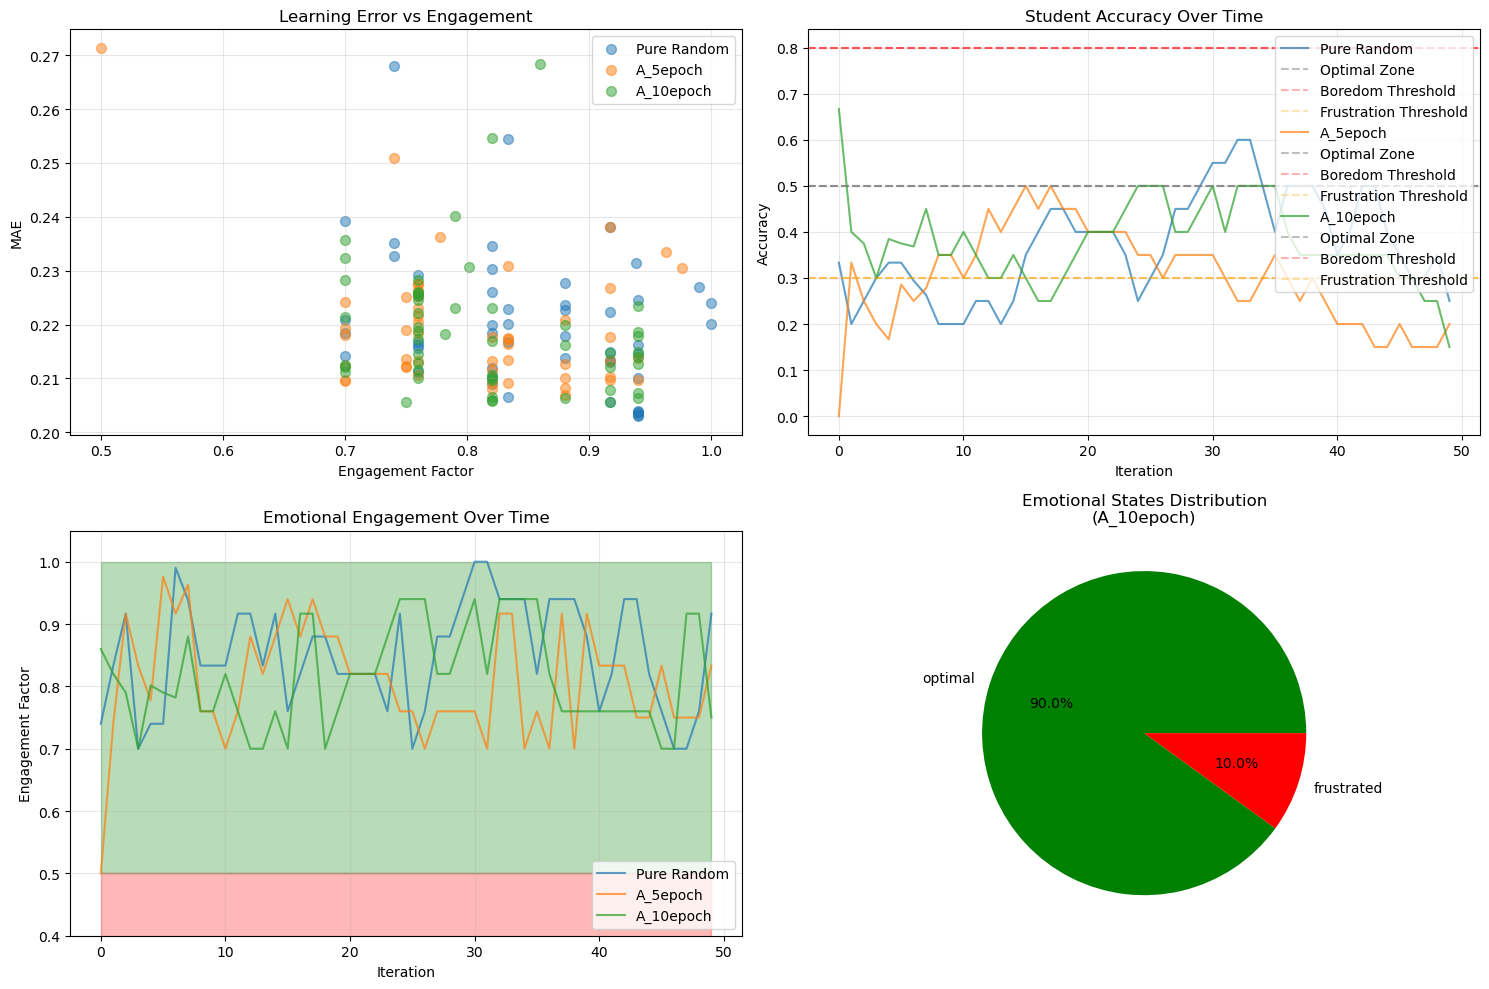


=== Engagement-Learning Correlation ===
Pure Random:
  MAE-Engagement Correlation: -0.318
  Avg Engagement: 85.19%
  Final MAE: 0.2223
A_5epoch:
  MAE-Engagement Correlation: -0.339
  Avg Engagement: 80.77%
  Final MAE: 0.2175
A_10epoch:
  MAE-Engagement Correlation: -0.204
  Avg Engagement: 81.52%
  Final MAE: 0.2056


In [ ]:
# Detailed Engagement-Learning Analysis: Random vs Boredom-Triggered Adaptive

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for mae_hist, engagement_hist, label in results:
    # Extract engagement and accuracy data
    engagements = [e['current_engagement'] for e in engagement_hist]
    accuracies = np.array([e['current_accuracy'] for e in engagement_hist])
    states = [e['current_state'] for e in engagement_hist]
    mae_values = np.array(mae_hist)
    
    # 1. MAE vs Engagement
    axes[0, 0].scatter(engagements, mae_values, alpha=0.5, label=label, s=50)
    
    # 2. Accuracy over time
    axes[0, 1].plot(accuracies, label=label, alpha=0.7, linewidth=2)
    axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Optimal Zone')
    axes[0, 1].axhline(y=0.8, color='red', linestyle='--', alpha=0.3, label='Boredom Threshold')
    axes[0, 1].axhline(y=0.3, color='orange', linestyle='--', alpha=0.3, label='Frustration Threshold')
    
    # 3. Engagement over time
    ax_color = 'green' if 'Adaptive' in label else 'blue'
    axes[1, 0].plot(engagements, label=label, alpha=0.7, linewidth=2, color=ax_color)
    
    # 4. State distribution pie chart
    state_dist = {}
    for e in engagement_hist:
        state = e['current_state']
        state_dist[state] = state_dist.get(state, 0) + 1
    
    if label == "Pure Random (No Adaptation)":
        colors_map = {'optimal': 'green', 'bored': 'blue', 'frustrated': 'red'}
        axes[1, 1].pie(state_dist.values(), labels=state_dist.keys(), autopct='%1.1f%%',
                      colors=[colors_map.get(s, 'gray') for s in state_dist.keys()],
                      startangle=90)
        axes[1, 1].set_title(f'State Distribution: {label}')

axes[0, 0].set_xlabel('Engagement Factor')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Learning Error vs Engagement')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Student Accuracy Over Time\n(Thresholds show Boredom/Frustration Zones)')
axes[0, 1].legend(loc='best', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Engagement Factor')
axes[1, 0].set_title('Engagement Factor Comparison')
axes[1, 0].fill_between(range(num_iterations), 0.5, 1.0, alpha=0.05, color='green', label='Optimal Zone')
axes[1, 0].fill_between(range(num_iterations), 0, 0.5, alpha=0.05, color='red', label='Disengaged Zone')
axes[1, 0].set_ylim([0.4, 1.05])
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print("\n=== Engagement-Learning Analysis ===")
for mae_hist, engagement_hist, label in results:
    engagements = np.array([e['current_engagement'] for e in engagement_hist])
    mae_values = np.array(mae_hist)
    accuracies = np.array([e['current_accuracy'] for e in engagement_hist])
    
    correlation = np.corrcoef(engagements, mae_values)[0, 1] if len(engagements) > 1 else 0
    
    print(f"\n{label}:")
    print(f"  MAE-Engagement Correlation: {correlation:.3f}")
    print(f"  Avg Engagement: {np.mean(engagements):.2%}")
    print(f"  Avg Accuracy: {np.mean(accuracies):.1%}")
    print(f"  Initial MAE: {mae_values[0]:.4f}")
    print(f"  Final MAE: {mae_values[-1]:.4f}")
    print(f"  MAE Improvement: {(mae_values[0] - mae_values[-1]) / mae_values[0] * 100:.1f}%")
    
    # State counts
    state_counts = {}
    for e in engagement_hist:
        s = e['current_state']
        state_counts[s] = state_counts.get(s, 0) + 1
    print(f"  Time in each state: {state_counts}")

print("\n=== Key Insight ===")
mae_random_final = results[0][0][-1]
mae_adaptive_final = results[1][0][-1]
improvement = (mae_random_final - mae_adaptive_final) / mae_random_final * 100 if mae_random_final > 0 else 0
print(f"Boredom-triggered adaptation provides {improvement:.1f}% MAE improvement vs pure random")



Training student with forget_factor=0.9


Student (λ=0.9): 100%|██████████| 58/58 [00:00<00:00, 5251.59it/s]



Training student with forget_factor=0.92


Student (λ=0.92): 100%|██████████| 58/58 [00:00<00:00, 6330.53it/s]



Training student with forget_factor=0.95


Student (λ=0.95): 100%|██████████| 58/58 [00:00<00:00, 5970.25it/s]


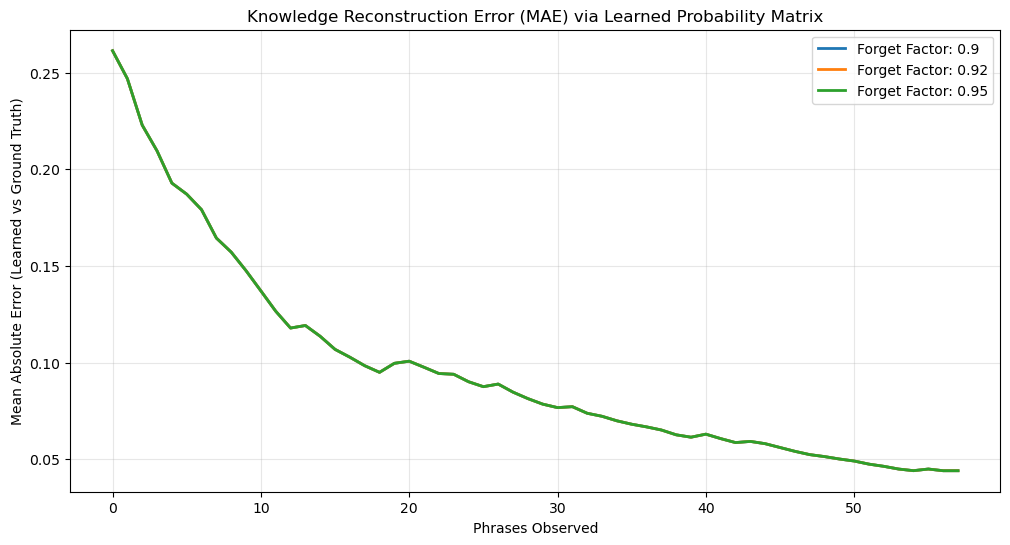


Student 0 (λ=0.9):
  Initial MAE: 0.2613
  Final MAE:   0.0441
  Improvement: 83.1%

Student 1 (λ=0.92):
  Initial MAE: 0.2613
  Final MAE:   0.0441
  Improvement: 83.1%

Student 2 (λ=0.95):
  Initial MAE: 0.2613
  Final MAE:   0.0441
  Improvement: 83.1%


In [34]:
collect_MAE = []
for student in student_group:
    print(f"\nTraining student with forget_factor={student.forget_factor}")
    mae_history = proc_study(student, material, ground_truth)
    collect_MAE.append(mae_history)


# 5. Visualization
plt.figure(figsize=(12, 6))
for i, mae_history in enumerate(collect_MAE):
    plt.plot(mae_history, label=f'Forget Factor: {forget_rates[i]}', linewidth=2)

plt.title("Knowledge Reconstruction Error (MAE) via Learned Probability Matrix")
plt.xlabel("Phrases Observed")
plt.ylabel("Mean Absolute Error (Learned vs Ground Truth)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print final performance
for i, (student, mae_hist) in enumerate(zip(student_group, collect_MAE)):
    print(f"\nStudent {i} (λ={forget_rates[i]}):")
    print(f"  Initial MAE: {mae_hist[0]:.4f}")
    print(f"  Final MAE:   {mae_hist[-1]:.4f}")
    print(f"  Improvement: {(mae_hist[0] - mae_hist[-1]) / mae_hist[0] * 100:.1f}%")
